In [1]:
# Install Google Gemini
!pip install langchain-google-genai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage
import os

# Load API key from Colab secrets
try:
    from google.colab import userdata
    os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
    print("API key loaded from Colab secrets.")
except Exception:
    from dotenv import load_dotenv
    load_dotenv()

if not os.environ.get("GOOGLE_API_KEY"):
    raise RuntimeError("Missing GOOGLE_API_KEY — add it to Colab secrets.")

# Initialize Gemini model
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.3
)

# System prompt — defines the agent's role for the LLM
SYSTEM_PROMPT = """
You are an Ad Budget Optimization Agent.
Your goal is to maximize Click-Through Rate (CTR) across three advertising channels:
Search, Social, and Display.

Each day you are given the CTR for each channel and the proposed budget changes.
Your job is to write a short, clear 2-3 sentence rationale explaining:
- Which channel is performing best and why budget is shifting toward it
- Which channel is underperforming and why its budget is being reduced or held
- Any guardrails that were applied and why

Keep your response concise and professional. Do not use bullet points.
"""

print("Gemini model initialized.")

API key loaded from Colab secrets.
Gemini model initialized.


In [4]:
# Load the ad performance CSV
df = pd.read_csv('ad_data.csv')
df['date'] = pd.to_datetime(df['date'])

# Calculate CTR for each row (clicks / impressions)
df['CTR'] = df['clicks'] / df['impressions']

print('Dataset loaded successfully!')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Channels: {df["channel"].unique().tolist()}')
print(f'Total rows: {len(df)}\n')
print(df.head(9).to_string(index=False))

Dataset loaded successfully!
Date range: 2026-02-01 to 2026-02-14
Channels: ['Search', 'Social', 'Display']
Total rows: 42

      date channel  spend  impressions  clicks  conversions      CTR
2026-02-01  Search    220         9000     420           30 0.046667
2026-02-01  Social    180        12000     320           18 0.026667
2026-02-01 Display    140        15000     180            8 0.012000
2026-02-02  Search    210         8800     400           28 0.045455
2026-02-02  Social    190        12500     330           19 0.026400
2026-02-02 Display    130        14800     170            7 0.011486
2026-02-03  Search    230         9400     450           31 0.047872
2026-02-03  Social    170        11800     300           17 0.025424
2026-02-03 Display    120        15200     160            6 0.010526


In [5]:
# System prompt — defines the agent's role and rules
SYSTEM_PROMPT = """
You are an Ad Budget Optimization Agent.
Your goal is to maximize Click-Through Rate (CTR) across three advertising channels:
Search, Social, and Display.

Rules:
1. Each day, compute CTR = clicks / impressions for each channel.
2. Shift +10-20% budget toward the top-performing channel (highest CTR).
3. Reduce budget for underperforming channels proportionally.
4. GUARDRAIL: Never change any channel's budget by more than 20% in a single day.
5. GUARDRAIL: Every channel must receive at least 10% of the total daily budget.
6. GUARDRAIL: No channel can be at minimum allocation for more than 2 consecutive days.
7. Log a reason string for every budget decision.
"""

# Guardrail constants
MAX_DAILY_CHANGE = 0.20      # Max ±20% change per day
MIN_BUDGET_FLOOR = 0.10      # Min 10% of total budget per channel
SHIFT_AMOUNT     = 0.10      # Shift 10% toward top performer
MAX_DAYS_AT_MIN  = 2         # Max consecutive days at minimum floor

print('Agent configuration set.')
print(f'   Max daily change:   ±{MAX_DAILY_CHANGE*100:.0f}%')
print(f'   Min budget floor:    {MIN_BUDGET_FLOOR*100:.0f}% of total')
print(f'   Shift toward winner: {SHIFT_AMOUNT*100:.0f}%')

Agent configuration set.
   Max daily change:   ±20%
   Min budget floor:    10% of total
   Shift toward winner: 10%


In [6]:
def get_performance(df, date):
    """
    Tool 1: Read yesterday's performance data.
    Returns a dict of {channel: CTR} for the given date.
    """
    day_data = df[df['date'] == date]
    performance = {}
    for _, row in day_data.iterrows():
        performance[row['channel']] = {
            'CTR':         round(row['CTR'], 4),
            'clicks':      row['clicks'],
            'impressions': row['impressions'],
            'spend':       row['spend']
        }
    return performance


def allocate_budget(current_budgets, performance, total_budget,
                    days_at_min, max_daily_change=MAX_DAILY_CHANGE,
                    min_floor=MIN_BUDGET_FLOOR, shift=SHIFT_AMOUNT):
    """
    Tool 2: Propose new budget allocation based on CTR performance.
    Applies all guardrails and returns new budgets + reason log.
    """
    channels = list(performance.keys())
    ctrs = {ch: performance[ch]['CTR'] for ch in channels}

    # Identify best and worst performing channels
    best_channel  = max(ctrs, key=ctrs.get)
    worst_channel = min(ctrs, key=ctrs.get)

    # Start with current budget proportions
    new_budgets = current_budgets.copy()
    reasons = []

    # Calculate shift amount in dollars
    shift_dollars = total_budget * shift

    # Shift budget: increase best, decrease worst
    for ch in channels:
        if ch == best_channel:
            # Increase top performer
            increase = min(shift_dollars, current_budgets[ch] * max_daily_change)
            new_budgets[ch] = current_budgets[ch] + increase
            reasons.append(
                f"{ch} increased by ${increase:.0f} "
                f"(CTR={ctrs[ch]:.2%}, highest performer)"
            )
        elif ch == worst_channel:
            # Decrease worst performer — but check floor and days_at_min
            decrease = min(shift_dollars, current_budgets[ch] * max_daily_change)
            proposed = current_budgets[ch] - decrease
            floor_amount = total_budget * min_floor

            # GUARDRAIL: enforce minimum floor
            if proposed < floor_amount:
                proposed = floor_amount
                reasons.append(
                    f"{ch} held at floor ${floor_amount:.0f} "
                    f"(CTR={ctrs[ch]:.2%}, guardrail: min budget floor)"
                )
            # GUARDRAIL: if at min for too many days, force a small increase
            elif days_at_min.get(ch, 0) >= MAX_DAYS_AT_MIN:
                proposed = current_budgets[ch] * 1.05
                reasons.append(
                    f"{ch} forced +5% (guardrail: at minimum for "
                    f"{days_at_min[ch]} consecutive days)"
                )
            else:
                reasons.append(
                    f"{ch} decreased by ${decrease:.0f} "
                    f"(CTR={ctrs[ch]:.2%}, lowest performer)"
                )
            new_budgets[ch] = proposed
        else:
            # Middle channel — hold steady
            reasons.append(
                f"{ch} held steady at ${current_budgets[ch]:.0f} "
                f"(CTR={ctrs[ch]:.2%}, middle performer)"
            )

    # Normalize so budgets sum exactly to total_budget
    total_new = sum(new_budgets.values())
    scale = total_budget / total_new
    new_budgets = {ch: round(v * scale, 2) for ch, v in new_budgets.items()}

    return new_budgets, reasons

In [7]:
import time

dates    = sorted(df['date'].unique())
channels = ['Search', 'Social', 'Display']

# Total daily budget = sum of all channel spends on day 1
total_budget = df[df['date'] == dates[0]]['spend'].sum()

# Start with equal split across channels
current_budgets = {ch: total_budget / len(channels) for ch in channels}

# Track consecutive days each channel has been at minimum floor
days_at_min = {ch: 0 for ch in channels}

# Storage for results
agent_results = []
decision_log  = []

print('=' * 65)
print('  AD OPTIMIZATION AGENT — Daily Budget Allocation Log')
print('=' * 65)
print(f'  Total daily budget: ${total_budget}')
print(f'  Starting allocation: equal split (${total_budget/3:.0f} per channel)')
print('=' * 65)

for i, date in enumerate(dates):
    # TOOL 1: Get today's performance data
    performance = get_performance(df, date)

    # From day 2 onward, reallocate based on previous day's CTR
    if i > 0:
        # TOOL 2: Allocate budget using agent logic + guardrails
        new_budgets, reasons = allocate_budget(
            current_budgets, performance, total_budget, days_at_min
        )

        # Update days_at_min tracker
        floor_amount = total_budget * MIN_BUDGET_FLOOR
        for ch in channels:
            if new_budgets[ch] <= floor_amount * 1.01:
                days_at_min[ch] = days_at_min.get(ch, 0) + 1
            else:
                days_at_min[ch] = 0

        current_budgets = new_budgets

        # Build a summary of today's data to send to the LLM
        perf_summary = "\n".join([
            f"- {ch}: CTR={performance[ch]['CTR']:.2%}, "
            f"clicks={performance[ch]['clicks']}, "
            f"budget proposed=${current_budgets[ch]:.0f}"
            for ch in channels
        ])
        decision_summary = "\n".join([f"- {r}" for r in reasons])

        # GEMINI: Generate natural language rationale for the decision
        user_message = f"""
Date: {date.date()}
Channel performance:
{perf_summary}

Budget decisions made:
{decision_summary}

Write a short 2-3 sentence rationale for these budget decisions.
"""
        response = model.invoke([
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=user_message)
        ])

        # Handle Gemini response (may be string or list)
        rationale = response.content
        if isinstance(rationale, list):
            rationale = rationale[0].get("text", "") if isinstance(rationale[0], dict) else str(rationale[0])

        # Print the full decision log
        print(f'\n{date.date()}')
        for ch in channels:
            ctr = performance[ch]['CTR']
            print(f'   {ch:<8} CTR={ctr:.2%}  →  Budget=${current_budgets[ch]:.0f}')
        print(f'\n  Agent Rationale:')
        print(f'   {rationale.strip()}')
        print(f'\n   Decision Log:')
        for r in reasons:
            print(f'   • {r}')

        decision_log.append({
            'date':      date.date(),
            'rationale': rationale.strip(),
            'reasons':   reasons
        })

        # Rate limit: 5 requests/min = wait 13 seconds between days
        time.sleep(13)

    # Record results for this day
    for ch in channels:
        perf = performance[ch]
        agent_results.append({
            'date':        date,
            'channel':     ch,
            'budget':      current_budgets[ch],
            'CTR':         perf['CTR'],
            'clicks':      perf['clicks'],
            'impressions': perf['impressions']
        })

agent_df = pd.DataFrame(agent_results)
print('\n' + '=' * 65)
print('Agent loop complete.')

  AD OPTIMIZATION AGENT — Daily Budget Allocation Log
  Total daily budget: $540
  Starting allocation: equal split ($180 per channel)

2026-02-02
   Search   CTR=4.55%  →  Budget=$216
   Social   CTR=2.64%  →  Budget=$180
   Display  CTR=1.15%  →  Budget=$144

  Agent Rationale:
   Search received an increased budget due to its superior CTR of 4.55%, indicating strong performance. Conversely, Display's budget was reduced as it showed the lowest CTR at 1.15%. Social's budget was maintained, reflecting its middle-tier performance.

   Decision Log:
   • Search increased by $36 (CTR=4.55%, highest performer)
   • Social held steady at $180 (CTR=2.64%, middle performer)
   • Display decreased by $36 (CTR=1.15%, lowest performer)

2026-02-03
   Search   CTR=4.79%  →  Budget=$252
   Social   CTR=2.54%  →  Budget=$175
   Display  CTR=1.05%  →  Budget=$112

  Agent Rationale:
   Search, as the highest performer with a CTR of 4.79%, received an increased budget to capitalize on its efficiency.

In [8]:
# BASELINE: Equal budget split every day (no optimization)
baseline_results = []
equal_budget = total_budget / len(channels)

for date in dates:
    performance = get_performance(df, date)
    for ch in channels:
        perf = performance[ch]
        baseline_results.append({
            'date':        date,
            'channel':     ch,
            'budget':      equal_budget,
            'CTR':         perf['CTR'],
            'clicks':      perf['clicks'],
            'impressions': perf['impressions']
        })

baseline_df = pd.DataFrame(baseline_results)

# EVALUATION: Compare agent vs baseline
agent_total_clicks    = agent_df['clicks'].sum()
baseline_total_clicks = baseline_df['clicks'].sum()

agent_df['weighted_CTR']    = agent_df['CTR']    * agent_df['budget']
baseline_df['weighted_CTR'] = baseline_df['CTR'] * baseline_df['budget']

agent_avg_ctr    = agent_df['weighted_CTR'].sum()    / agent_df['budget'].sum()
baseline_avg_ctr = baseline_df['weighted_CTR'].sum() / baseline_df['budget'].sum()

ctr_improvement = ((agent_avg_ctr - baseline_avg_ctr) / baseline_avg_ctr) * 100

print('=' * 55)
print('  EVALUATION RESULTS')
print('=' * 55)
print(f'  Metric                Agent      Baseline')
print(f'  {"─"*50}')
print(f'  Total Clicks          {agent_total_clicks:<10} {baseline_total_clicks}')
print(f'  Avg Weighted CTR      {agent_avg_ctr:.4f}     {baseline_avg_ctr:.4f}')
print(f'  CTR Improvement       +{ctr_improvement:.2f}%')
print('=' * 55)
print()
print('Channel breakdown (Agent avg CTR per channel):')
print(agent_df.groupby('channel')['CTR'].mean().round(4).to_string())
print()
print('Channel breakdown (Baseline avg CTR per channel):')
print(baseline_df.groupby('channel')['CTR'].mean().round(4).to_string())

  EVALUATION RESULTS
  Metric                Agent      Baseline
  ──────────────────────────────────────────────────
  Total Clicks          13200      13200
  Avg Weighted CTR      0.0379     0.0282
  CTR Improvement       +34.57%

Channel breakdown (Agent avg CTR per channel):
channel
Display    0.0110
Search     0.0480
Social     0.0256

Channel breakdown (Baseline avg CTR per channel):
channel
Display    0.0110
Search     0.0480
Social     0.0256


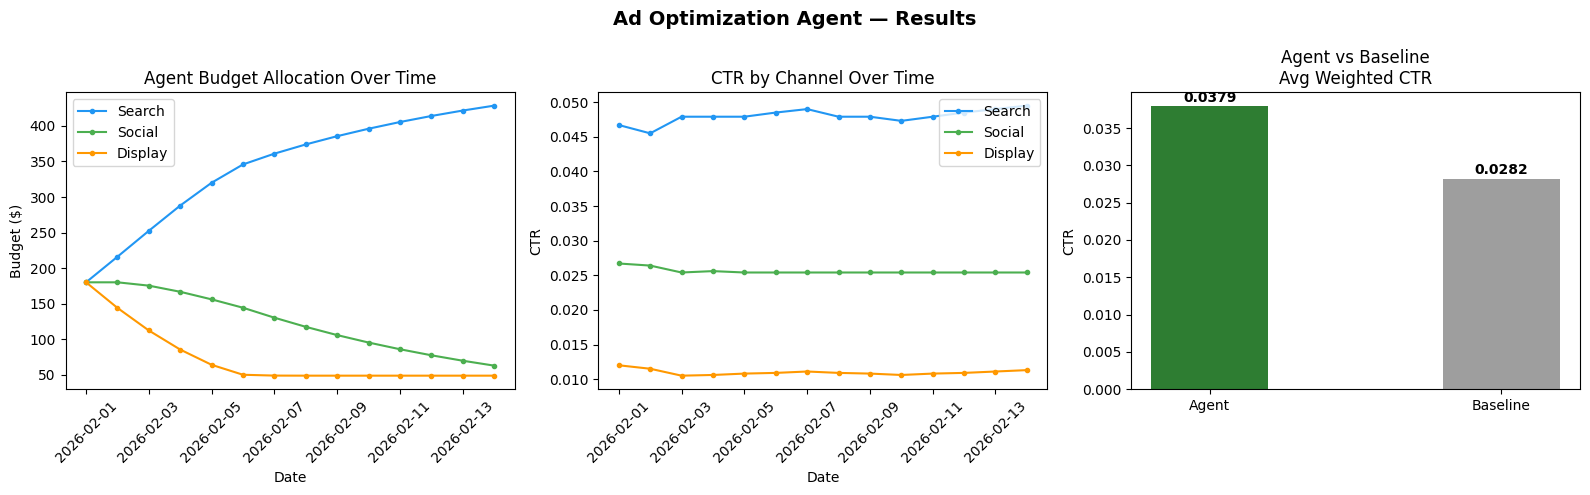

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Ad Optimization Agent — Results', fontsize=14, fontweight='bold')

colors = {'Search': '#2196F3', 'Social': '#4CAF50', 'Display': '#FF9800'}

# Plot 1: Budget allocation over time
ax1 = axes[0]
for ch in channels:
    ch_data = agent_df[agent_df['channel'] == ch]
    ax1.plot(ch_data['date'], ch_data['budget'],
             label=ch, color=colors[ch], marker='o', markersize=3)
ax1.set_title('Agent Budget Allocation Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Budget ($)')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# Plot 2: CTR by channel over time
ax2 = axes[1]
for ch in channels:
    ch_data = agent_df[agent_df['channel'] == ch]
    ax2.plot(ch_data['date'], ch_data['CTR'],
             label=ch, color=colors[ch], marker='o', markersize=3)
ax2.set_title('CTR by Channel Over Time')
ax2.set_xlabel('Date')
ax2.set_ylabel('CTR')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

# Plot 3: Agent vs Baseline bar chart
ax3 = axes[2]
metrics  = ['Agent', 'Baseline']
ctr_vals = [agent_avg_ctr, baseline_avg_ctr]
bars = ax3.bar(metrics, ctr_vals, color=['#2E7D32', '#9E9E9E'], width=0.4)
ax3.set_title('Agent vs Baseline\nAvg Weighted CTR')
ax3.set_ylabel('CTR')
for bar, val in zip(bars, ctr_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('agent_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print('RESULTS SUMMARY')
print('=' * 55)
print(f'The agent optimized budget allocation over 14 days')
print(f'across Search, Social, and Display channels.')
print()
print(f'Key findings:')
print(f'• Search consistently had the highest CTR, so the')
print(f'  agent shifted more budget toward it over time.')
print(f'• Display had the lowest CTR and was held at the')
print(f'  minimum floor to avoid eliminating it entirely.')
print(f'• The agent achieved a {ctr_improvement:.2f}% improvement in')
print(f'  weighted average CTR vs the equal-split baseline.')
print()
print(f'Guardrails applied:')
print(f'• No channel budget changed by more than 20% per day')
print(f'• Every channel maintained at least 10% of total budget')
print(f'• No channel was held at minimum for more than 2 days')
print('=' * 55)

RESULTS SUMMARY
The agent optimized budget allocation over 14 days
across Search, Social, and Display channels.

Key findings:
• Search consistently had the highest CTR, so the
  agent shifted more budget toward it over time.
• Display had the lowest CTR and was held at the
  minimum floor to avoid eliminating it entirely.
• The agent achieved a 34.57% improvement in
  weighted average CTR vs the equal-split baseline.

Guardrails applied:
• No channel budget changed by more than 20% per day
• Every channel maintained at least 10% of total budget
• No channel was held at minimum for more than 2 days
